# Chapitre 5 : Méthode de Newton et quasi-Newton (I)

La méthode de Newton est une méthode de recherche de zéros d'une fonction $F : \mathbb{R}^n \to \mathbb{R}^n$, autrement dit on résout $F(x) = 0$.

Comme on a déjà vu, pour les problème d'optimisation sans contrainte, la condition nécessaire du premier ordre est $\nabla f(x^\star) = 0$. Si on suppose que $F(x)=\nabla f(x^\star)$, la méthode de Newton peut nous aider à résoudre les problèmes d'optimisation.

**But.** Il s’agit de mettre en œuvre la méthode de Newton et d’en estimer la vitesse de convergence
numériquement dans différentes situations élémentaires, puis de traiter des cas d’application plus riches.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

## I. (25min) Méthode de Newton

1. Pour une fonction $f:\mathbb R^n\to\mathbb R$ deux fois différentiable en $x_k$, écrire sa formule de Taylor-Young au second ordre au point $x$.

**Reponse.**
$$f(x) = f(x_k)+\langle \nabla f(x_k),x-x_k\rangle+\frac{1}{2}\langle H_f(x_k)\cdot(x-x_k),x-x_k\rangle+\|x-x_k\|^2\varepsilon(x-x_k)$$
avec $\lim_{x_k\to x}\varepsilon(x-x_k)=0$.

2. Notons $g$ l'approximation de degré 2 de la fonction $f$ au point $x$. En supposant que $g$ admette un unique minimum, donner la formule de ce minimum.

**Reponse.**
Soit une fonction $g:\mathbb R^n\to\mathbb R$ définie par
$$g(x) = g(x_k)+\langle \nabla g(x_k),x-x_k\rangle+\frac{1}{2}\langle H_g(x_k)\cdot(x-x_k),x-x_k\rangle$$ qui est donc l'approximation d'ordre deux de $f$ au voisinage de $x$. Cette fonction $g$ est une fonctionnelle quadratique. Elle est donc minimale
pour $x = x_k-H_g(x_k)^{-1}\cdot\nabla g(x_k)$.

3. Nous avons défini la direction de descente $d$ au point $x^*$ si $f(x^*+\lambda.d)\leq f(x^*)$. Ici, nous définissons la taille du pas $\lambda = 1$, donc pour chaque point $x_k$, nous pouvons obtenir la direction de descente correspondante $d_k = x_{k+1} - x_k$.

a). Donner la définition de la méthode de Newton.

**Reponse.**
La méthode de Newton est définie par une valeur initiale $x_0$ et par la relation de récurrence $$x_{k+1} = x_{k} - H_f(x_k)^{-1}\cdot\nabla f(x_k)$$ tant que la matrice hessienne $H_f(x_k)$ est inversible et tant que $\nabla f(x_k) \neq 0$.

b). Résumer le processus itératif de l'algorithme de la méthode de Newton.

**Reponse.**

**Données :** Un point initial $x_0 \in \mathbb{R}^n$, un nombre maximum d'itérés $N$, un seuil de tolérance $\varepsilon > 0$

**Résultat :** Un point $x \in \mathbb{R}^n$ proche de $x^\star$

*Initialiser :* $x \leftarrow x_0$, $k \leftarrow 0$

*Tant que* $\|\nabla f(x_k)\|\geq\varepsilon$ et $k<N$:

$\quad$ *Étape 1.* Calculer $d_k=-H_f(x_k)^{-1}\cdot\nabla f(x_k)$.

$\quad$ *Étape 2.* Mettre à jour $x$ : $x \leftarrow  x_{k+1} = x_k + d_k$

$\quad$ *Étape 3.* $k \leftarrow  k + 1$

*Retourner* $x$

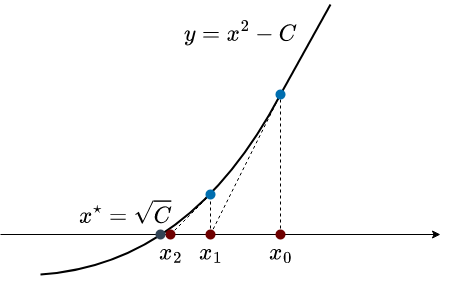

### I.1. Exemple 1

Soit la fonction objectif $f(x)=\frac{1}{3}x^3-3x$, avec $x\in\mathbb R$ et $c\in\mathbb R$.
Calculer son gradient et sa matrice hessienne, et trouver le minimum local de cette fonction avec Python.

In [2]:
def newton_descent(x_start, obj_func, gradient_func, hessien_func, max_iter:int, tol = 0.001):
    
    # x_start: point initial
    # obj_func: fonction objective
    # gradient_func: gradient de la fonction objective
    # hessien_func: hessienne de la fonction objective
    # max_iter: nombre maximum d'itérations
    # tol: tolérance
    
    x = x_start
    obj = list()
        
    for _ in tqdm( range(max_iter) ):
        # Calculer le gradient et la hessienne à ce point
        ### votre code (2 lignes) ###
        myhess = hessien_func(x)
        mygrad = gradient_func(x)
        ############ fin ############
         
        # Pas échelonné (gradient / hessienne)
        ### votre code (1 ligne) ###
        diff = mygrad/myhess
        ############ fin ############  
        
        # Arrêter si la pente mise à l'échelle est inférieure à la tolérance
        ### votre code (2 lignes) ###
        if np.abs(diff)<=tol:
            break 
        ############ fin ############
        
        # Effectuez un pas proportionnel
        ### votre code (1 lignes) ###
        x -= diff 
        ############ fin ############
        # traçage de l'histoire
        obj.append(obj_func(x) ) 

    return obj, x

In [3]:
# Définir la fonction objectif, la fonction de gradient et la fonction de hessienne
### votre code (3 lignes) ###
myobj = lambda x: x**3/3-3*x
mygradient = lambda x: x**2-3
myhessien = lambda x: 2*x
############ fin ############

myparams = dict(obj_func = myobj, gradient_func = mygradient, hessien_func = myhessien, max_iter = 10, tol = 1e-10)
obj, x = newton_descent(x_start = 10, **myparams)


 70%|████████████████████████████▋            | 7/10 [00:00<00:00, 20403.15it/s]


In [4]:
x

1.7320508075688774

### I.2. Exemple 2

Soit la fonction objectif $f(x)=\frac{1}{4}x^4-\frac{1}{4}x^2+x+1$, avec $x\in\mathbb R$ et $c\in\mathbb R$.
Calculer son gradient et sa matrice hessienne, et trouver le minimum local de cette fonction avec Python.

In [5]:
# Définir la fonction objectif, la fonction de gradient et la fonction de hessienne
### votre code (3 lignes) ###
myobj = lambda x: x**4/4 - x**2/2 + x + 1
mygradient = lambda x: x**3 - x/2 + 1
myhessien = lambda x: 3*x**2 - 1/2
############ fin ############

myparams = dict(obj_func = myobj, gradient_func = mygradient, hessien_func = myhessien, max_iter = 20, tol = 1e-3)
obj, x = newton_descent(x_start = 10, **myparams)

100%|████████████████████████████████████████| 20/20 [00:00<00:00, 30492.94it/s]


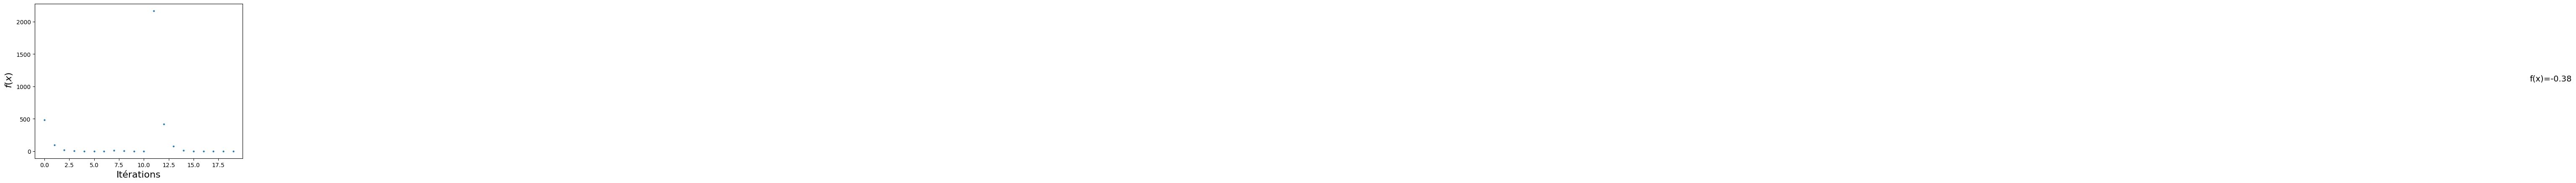

In [6]:
plt.plot(obj, 'o', ms=2)
plt.xlabel('Itérations', fontsize=16)
plt.ylabel(' $f(x)$', fontsize=16)
plt.text(250,np.max(obj)/2., f'f(x)={obj[-1]:2.2f}', fontsize=14);

Veuillez vérifier l'effet des différentes valeurs initiales, des différentes conditions de terminaison et des différentes étapes d'itération sur les résultats.

In [7]:
import math
# par exemple : x0 = math.sqrt(1/6)*(1+1e-16)

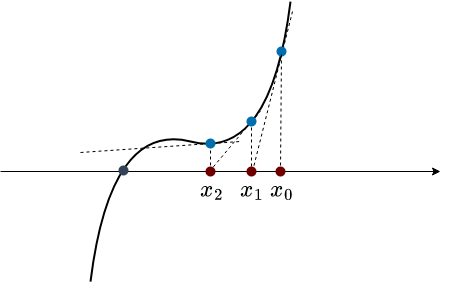

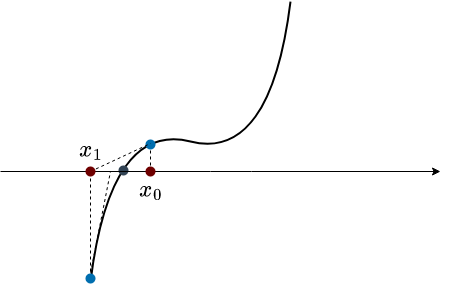

### I.3. Résumer les situations où la méthode de Newton est applicable :
1. Le point initial sélectionné est suffisamment proche de zéro
2. La fonction est une fonction de classe $\mathrm C^{\infty}$ (contre-exemple : les zéros de fonction $x^{\frac{1}{3}}$)

### I.4. Exercice

Programmer la méthode de Newton pour une fonction $f$, de différentielle $df$ qui sera supposée calculable explicitement. Distinguer les cas monodimensionnel et multidimensionnel.
Pour cela, écrire une fonction `newton_descent(x_start, gradient_func, hessien_func, max_iter, tol)` qui, pour une donnée initiale $x_{\text{start}}$, contient la boucle principale $x=x-f(x)/df(x)$ dans laquelle $f$ est la fonction étudiée et $df$ sa dérivée.

In [8]:
def newton_descent(x_start, gradient_func, hessien_func, max_iter:int, tol = 0.001):
    
    # x_start: point initial
    # gradient_func: gradient de la fonction objective
    # hessien_func: hessienne de la fonction objective
    # max_iter: nombre maximum d'itérations
    # tol: tolérance
    
    x = x_start
    it_conv = 0
    x_list = list()
        
    while it_conv in range(max_iter):
        # Calculer le gradient et la hessienne à ce point
        ### votre code (2 lignes) ###
        mygrad = gradient_func(x)
        myhess = hessien_func(x)
        ############ fin ############
         
        # Pas échelonné (hessienne^-1 * gradient)
        ### votre code (1 ligne) ###
        diff = mygrad/myhess
        ############ fin ############  
        
        if np.abs(diff)<=tol:
            break
        
        # Effectuez un pas proportionnel
        ### votre code (1 ligne) ###
        x -= diff
        ############ fin ############
        it_conv += 1
        # traçage de l'histoire
        x_list.append(x) 

    return x_list, it_conv

1. (3min) Tester la méthode sur l’exemple monodimensionnel $f_1(x) = e^{2x} − e = 0$, illustrer graphiquement la vitesse de convergence puis la quantifier.

In [9]:
# Définir la fonction objectif, la fonction de gradient et la fonction de hessienne
### votre code (2 lignes) ###
mygradient1 = lambda x: np.exp(2*x)-np.e
myhessien1 = lambda x: 2*np.exp(2*x)
############ fin ############

1.a. (3min) On commence par le cas théorique où le nombre de pas $N$ est imposé. La commande de sortie return $x$ renvoie le $N$ ième itéré.
- La méthode converge après combien de pas ?
- Tester ce programme avec la fonction $f_1$ en partant des données `x0=5`, `N=20` et `eps=1e-6`.

In [10]:
myparams = dict(gradient_func = mygradient1, hessien_func = myhessien1, max_iter = 20, tol = 1e-6)
x_list, it_conv = newton_descent(x_start = 5, **myparams)

print('La méthode converge en ',it_conv,'pas') 
## résultat désiré : 13

La méthode converge en  13 pas


1.b. Tracer la suite des itérés sur le graphe de $f$.

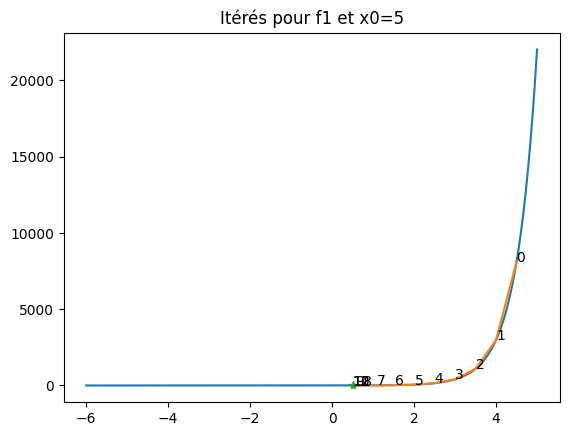

In [11]:
tabxeff = np.array(x_list)
tabyeff = mygradient1(tabxeff)

# Graphe des itérés

t = np.linspace(-6,5,200)
yt = mygradient1(t)
#plt.plot(t,yt,tabxeff,tabcriteff,tabxeff[-1],tabcriteff[-1],'*')
plt.plot(t,yt)
plt.plot(np.array(tabxeff),np.array(tabyeff))
plt.plot(tabxeff[-1],tabyeff[-1],'*')
for i in range(it_conv):
    plt.text(tabxeff[i],tabyeff[i],s=str(i))
plt.title('Itérés pour f1 et x0=5')
plt.show()

2. Utiliser la méthode de Newton pour la résolution du système polynomial suivant
\begin{equation*}
    \left\{\begin{aligned}x_1^2+x_2^2=2\\x_1^2-x_2^2=1\end{aligned}\right.
\end{equation*}
Illustrer de nouveau la convergence une première fois en traçant les itérés dans le plan $(x_1, x_2)$, et ensuite en quantifiant l’erreur et l’ordre de convergence. Tester plusieurs initialisations.

2.a. Ecrire la version multidimensionnelle de Newton en tenant compte des modifications suivantes
- **Tracer l’évolution du critère crit comme dans le cas monodimensionnel.**
- **Tracer les itérés sur le graphe représentant l’ensemble des solutions comme intersection du cercle $x_1^2 + x_2^2 = 2$ et de l’hyperbole $x_1^2 − x_2^2 = 1$.**

In [12]:
def newton_descent(x_start, gradient_func, hessien_func, max_iter:int, tol = 1e-6):
    
    # x_start: point initial
    # gradient_func: gradient de la fonction objective
    # hessien_func: hessienne de la fonction objective
    # max_iter: nombre maximum d'itérations
    # tol: tolérance
    
    x = x_start
    x_list = list()
    x1_list = list()
    x2_list = list()
    x_list.append(np.array(x_start))
    x1_list.append(np.array(x_start)[0])
    x2_list.append(np.array(x_start)[1])
        
    for i in range(max_iter):
        # Calculer le gradient et la hessienne à ce point
        ### votre code (2 lignes) ###
        mygrad = gradient_func(x)
        myhess = hessien_func(x)
        ############ fin ############
         
        # Pas échelonné (hessienne^-1 * gradient)
        ### votre code (1 ligne) ###
        diff = np.dot(np.linalg.inv(myhess), mygrad)
        ############ fin ############  
        
        # Arrêter si la pente mise à l'échelle est inférieure à la tolérance
        ### votre code (2 lignes) ###
        if np.sum(np.abs(diff))<=tol:
            break 
        ############ fin ############
        
        # Effectuez un pas proportionnel
        ### votre code (1 ligne) ###
        x -= diff
        ############ fin ############
        x_list.append(np.array(x))
        x1_list.append(np.array(x)[0])
        x2_list.append(np.array(x)[1])

    return x_list, x1_list, x2_list

1.b. Tracer la suite des itérés sur le graphe de $f$.

In [13]:
# Définir la fonction de gradient et la fonction de hessienne
### votre code (2 lignes) ###
mygradient2 = lambda p: [p[0]**2+p[1]**2-2, p[0]**2-p[1]**2-1]
myhessien2 = lambda p: [[2*p[0], 2*p[1]], [2*p[0], -2*p[1]]]
############ fin ############

In [14]:
p = (-3,5) # hessienne à point p(-3,5)
myhessien2(p)
## résultat désiré : array([[ -6,  10], [ -6, -10]])

[[-6, 10], [-6, -10]]

In [15]:
#x0 = np.array([3,5]) #x0 = np.array([-0.5,0.5])

myparams = dict(gradient_func = mygradient2, hessien_func = myhessien2, max_iter = 1000, tol = 1e-6)
x_list, x1_list, x2_list = newton_descent(x_start = [-0.5,0.5] , **myparams)

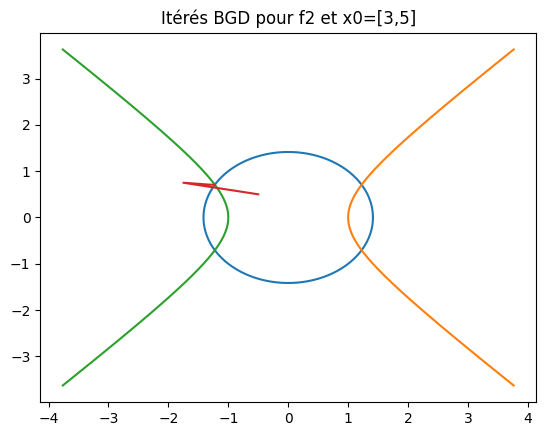

In [16]:
tabxeff = np.array(x1_list)
tabyeff = np.array(x2_list)

t = np.linspace(0,2*np.pi,100) # le cercle
r = np.sqrt(2)
xt = r*np.cos(t)
yt = r*np.sin(t)

s = np.linspace(-2,2,600) # l'hyperbole
xs = np.cosh(s)
ys = np.sinh(s)

plt.plot(xt,yt)
plt.plot(xs,ys)
plt.plot(-xs,ys)
plt.plot(tabxeff,tabyeff)
plt.title('Itérés BGD pour f2 et x0=[3,5]')
plt.show()